In [1]:
# fonction.py est resté à la racine du projet (partagé par tous les
# notebooks) : chaque notebook vivant maintenant dans son propre
# dossier, on ajoute le dossier parent au chemin d'import.
import sys, os
sys.path.append(os.path.abspath('..'))

from fonction import *
import numpy as np

### Étude de convergence : raffinement du maillage

On vérifie ici que le schéma Volumes Finis converge bien vers la solution
exacte lorsque le maillage est raffiné (Nx croissant, donc dx décroissant),
et on estime son **ordre de convergence** (cf. section 6 du sujet).

Un schéma d'ordre p vérifie erreur ≈ C · dx^p, donc en échelle log-log :
ln(erreur) ≈ p · ln(dx) + cste — la pente de la droite donne l'ordre p.

In [2]:
Nx_list = [200, 400, 800, 1600, 3200] # maillages de plus en plus fins

L1_list = []
L2_list = []
Linf_list = []
dx_list = []

for i in Nx_list:
    x_VF, t_VF, U_num = u_volume_finie(Nx=i)
    dx = x_VF[1] - x_VF[0]
    idx = np.argmin(np.abs(t_VF - 3)) # on compare toujours au même instant t=3

    U_exacte_3 = u_analytique(x_VF, t_VF[idx], A, x0, sigma, D, alpha)
    U_num_3 = U_num[idx, :]
    diff = U_num_3 - U_exacte_3
    L1_n = dx * np.sum(np.abs(diff)) # erreur L1 (norme absolue intégrée)
    L2_n, Linf_n = erreurs_L2_Linf(x_VF, U_num_3, U_exacte_3, dx)
    L1_list.append(L1_n)
    L2_list.append(L2_n)
    Linf_list.append(Linf_n)
    dx_list.append(dx)

    print(f"Nx={i:5d}  |  dx={dx:.6f}  |  t_VF[idx]={t_VF[idx]:.4f}  |  "
          f"L2={L2_n:.3e}  |  Linf={Linf_n:.3e}")

# --- Récapitulatif des erreurs pour chaque maillage -------------------------
df_convergence = pd.DataFrame({
    'Nx': Nx_list,
    'dx': dx_list,
    'L1': L1_list,
    'L2': L2_list,
    'Linf': Linf_list
})

print(df_convergence)

df_convergence.to_csv('convergence_maillage.csv', index=False)


Nx=  200  |  dx=0.100000  |  t_VF[idx]=3.0018  |  L2=3.494e-05  |  Linf=2.055e-05
Nx=  400  |  dx=0.050000  |  t_VF[idx]=2.9995  |  L2=5.742e-06  |  Linf=2.799e-06
Nx=  800  |  dx=0.025000  |  t_VF[idx]=2.9999  |  L2=1.197e-06  |  Linf=5.647e-07
Nx= 1600  |  dx=0.012500  |  t_VF[idx]=3.0000  |  L2=5.460e-07  |  Linf=3.216e-07
Nx= 3200  |  dx=0.006250  |  t_VF[idx]=3.0000  |  L2=8.968e-08  |  Linf=4.372e-08
     Nx       dx            L1            L2          Linf
0   200  0.10000  1.064656e-04  3.493855e-05  2.055416e-05
1   400  0.05000  1.897829e-05  5.742155e-06  2.798558e-06
2   800  0.02500  3.917025e-06  1.196629e-06  5.647105e-07
3  1600  0.01250  1.663683e-06  5.459503e-07  3.215567e-07
4  3200  0.00625  2.964703e-07  8.968123e-08  4.371821e-08


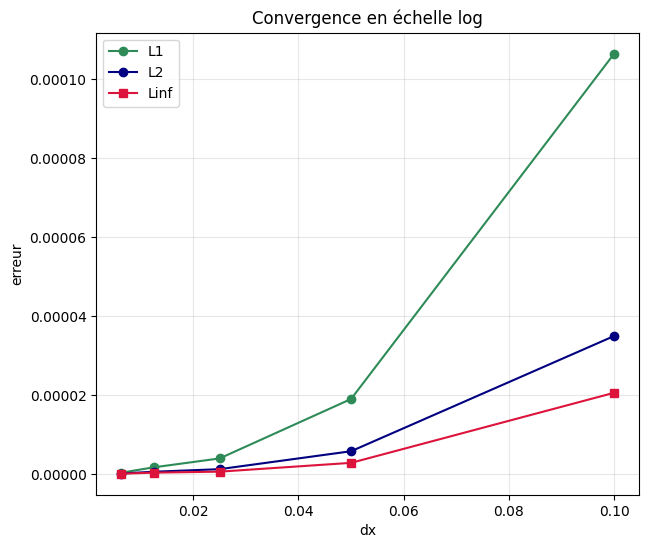

In [3]:
# --- Visualisation de la décroissance de l'erreur avec dx (échelle log-log) -
plt.figure(figsize=(7, 6))
plt.plot(dx_list, L1_list, 'o-', label="L1", color='seagreen')
plt.plot(dx_list, L2_list, 'o-', label="L2", color='navy')
plt.plot(dx_list, Linf_list, 's-', label="Linf", color='crimson')
plt.xlabel('dx')
plt.ylabel('erreur')
plt.title(f"Convergence en échelle log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('convergence_loglog.png', dpi=300, bbox_inches='tight')
plt.show()

Ordre de convergence estimé (L1)   : 2.05
Ordre de convergence estimé (L2)   : 2.06
Ordre de convergence estimé (Linf) : 2.09


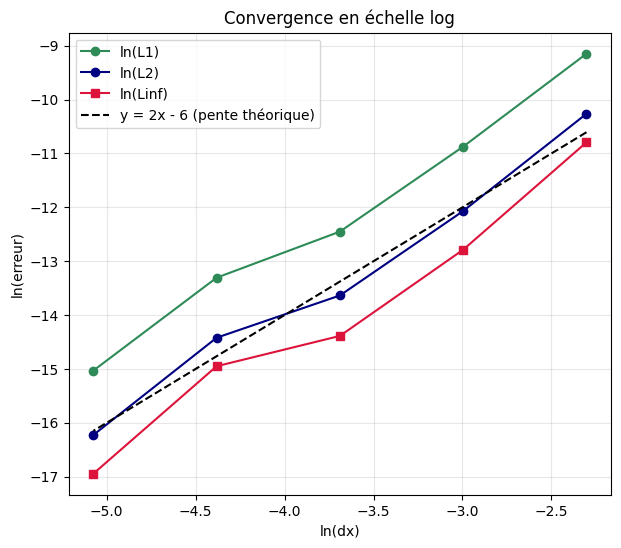

In [4]:
# --- Estimation de l'ordre de convergence par régression linéaire ----------
# En échelle log-log, la pente de ln(erreur) en fonction de ln(dx) donne
# directement l'ordre p du schéma (erreur ~ dx^p).
ln_dx = np.log(dx_list)
ln_L1 = np.log(L1_list)
ln_L2 = np.log(L2_list)
ln_Linf = np.log(Linf_list)

# Estimation de la pente (= ordre de convergence) par régression linéaire
pente_L2 = np.polyfit(ln_dx, ln_L2, 1)[0]
pente_Linf = np.polyfit(ln_dx, ln_Linf, 1)[0]
pente_L1 = np.polyfit(ln_dx, ln_L1, 1)[0]
print(f"Ordre de convergence estimé (L1)   : {pente_L1:.2f}")
print(f"Ordre de convergence estimé (L2)   : {pente_L2:.2f}")
print(f"Ordre de convergence estimé (Linf) : {pente_Linf:.2f}")

# Pente théorique attendue pour un schéma d'ordre 2 (référence visuelle)
y_theorique = 2 * ln_dx - 6

plt.figure(figsize=(7, 6))
plt.plot(ln_dx, ln_L1, 'o-', label="ln(L1)", color='seagreen')
plt.plot(ln_dx, ln_L2, 'o-', label="ln(L2)", color='navy')
plt.plot(ln_dx, ln_Linf, 's-', label="ln(Linf)", color='crimson')
plt.plot(ln_dx, y_theorique, 'k--', label="y = 2x - 6 (pente théorique)")
plt.xlabel('ln(dx)')
plt.ylabel('ln(erreur)')
plt.title(f"Convergence en échelle log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('convergence_log.png', dpi=300, bbox_inches='tight')
plt.show()